In [1]:
# ============================================================
# 1. Imports + Device Setup
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import os
import json
import pandas as pd

In [2]:
# ============================================================
# 1.1 Reproducibility + Device
# ============================================================

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

os.makedirs("./models", exist_ok=True)
os.makedirs("./results", exist_ok=True)

Using device: cuda


In [3]:
# ============================================================
# 2. Image Transforms
# ============================================================

IMG_SIZE = 160

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    transforms.RandomErasing(
        p=0.25,
        scale=(0.02, 0.12),
        ratio=(0.3, 3.3)
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Note: using ImageNet mean/std as normalization values.
# These are standard for natural image datasets and close to
# the values computed from this dataset in section 4.4
# (mean=[0.478, 0.446, 0.396], std=[0.263, 0.258, 0.265]).

In [4]:
# ============================================================
# 3. Load Oxford-IIIT Pet Dataset
# ============================================================

full_train_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    transform=train_transform,
    download=True
)

full_eval_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    transform=eval_transform,
    download=True
)

test_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="test",
    target_types="category",
    transform=eval_transform,
    download=True
)

class_names = full_train_dataset.classes
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Training + validation images:", len(full_train_dataset))
print("Test images:", len(test_dataset))

100%|██████████| 792M/792M [00:37<00:00, 21.1MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 7.47MB/s]


Number of classes: 37
Training + validation images: 3680
Test images: 3669


Number of classes: 37
Trainval dataset size: 3680
Test dataset size: 3669
Total dataset size: 7349


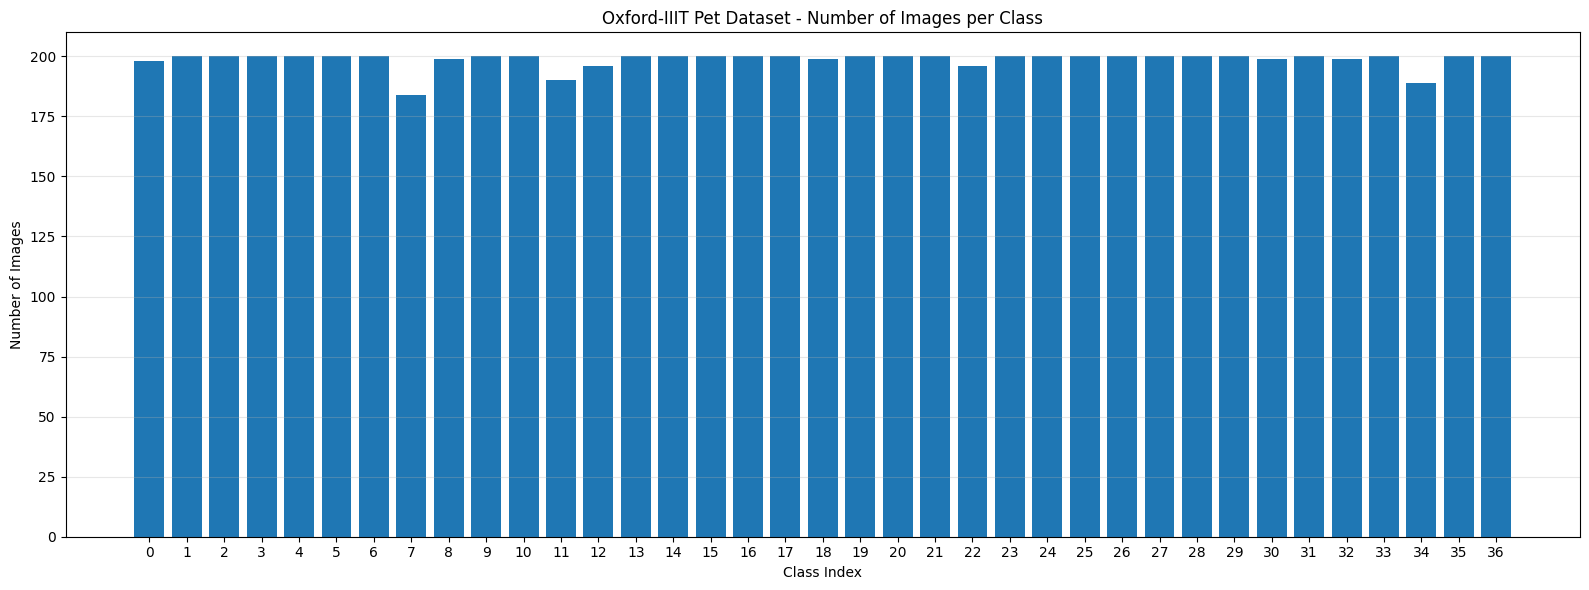

Min: 184
Max: 200
Avg: 198.6


In [5]:
# ============================================================
# 4.1 Exploratory Data Analysis - Class Distribution
# ============================================================

from collections import Counter

# Use only EDA-prefixed variables to avoid interfering with training code
eda_trainval_labels = [label for _, label in full_train_dataset]
eda_test_labels = [label for _, label in test_dataset]

# Total labels = trainval + test
eda_all_labels = eda_trainval_labels + eda_test_labels
eda_all_counts = Counter(eda_all_labels)

print("Number of classes:", num_classes)
print("Trainval dataset size:", len(full_train_dataset))
print("Test dataset size:", len(test_dataset))
print("Total dataset size:", len(full_train_dataset) + len(test_dataset))

# Convert counts to lists ordered by class index
eda_class_indices = list(range(num_classes))
eda_total_values = [eda_all_counts[i] for i in eda_class_indices]

plt.figure(figsize=(16, 6))

plt.bar(eda_class_indices, eda_total_values)

plt.xlabel("Class Index")
plt.ylabel("Number of Images")
plt.title("Oxford-IIIT Pet Dataset - Number of Images per Class")
plt.xticks(eda_class_indices)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("./results/eda_class_distribution.png", dpi=150)
plt.show()

print("Min:", min(eda_total_values))
print("Max:", max(eda_total_values))
print("Avg:", round(sum(eda_total_values) / len(eda_total_values), 1))

In [6]:
# ============================================================
# 4.2 Exploratory Data Analysis - Class Distribution Table
# ============================================================

eda_distribution_rows = []

for eda_idx in range(num_classes):
    eda_distribution_rows.append({
        "class_index": eda_idx,
        "class_name": class_names[eda_idx],
        "total_count": eda_all_counts[eda_idx]
    })

eda_distribution_df = pd.DataFrame(eda_distribution_rows)

display(
    eda_distribution_df
    .sort_values("total_count", ascending=False)
    .reset_index(drop=True)
)

print("Minimum images per class:", eda_distribution_df["total_count"].min())
print("Maximum images per class:", eda_distribution_df["total_count"].max())
print("Average images per class:", round(eda_distribution_df["total_count"].mean(), 1))

,class_index,class_name,total_count
0,1,American Bulldog,200
1,3,Basset Hound,200
2,2,American Pit Bull Terrier,200
3,4,Beagle,200
4,5,Bengal,200
5,36,Yorkshire Terrier,200
6,6,Birman,200
7,10,Chihuahua,200
8,9,British Shorthair,200
9,16,Havanese,200


Minimum images per class: 184
Maximum images per class: 200
Average images per class: 198.6


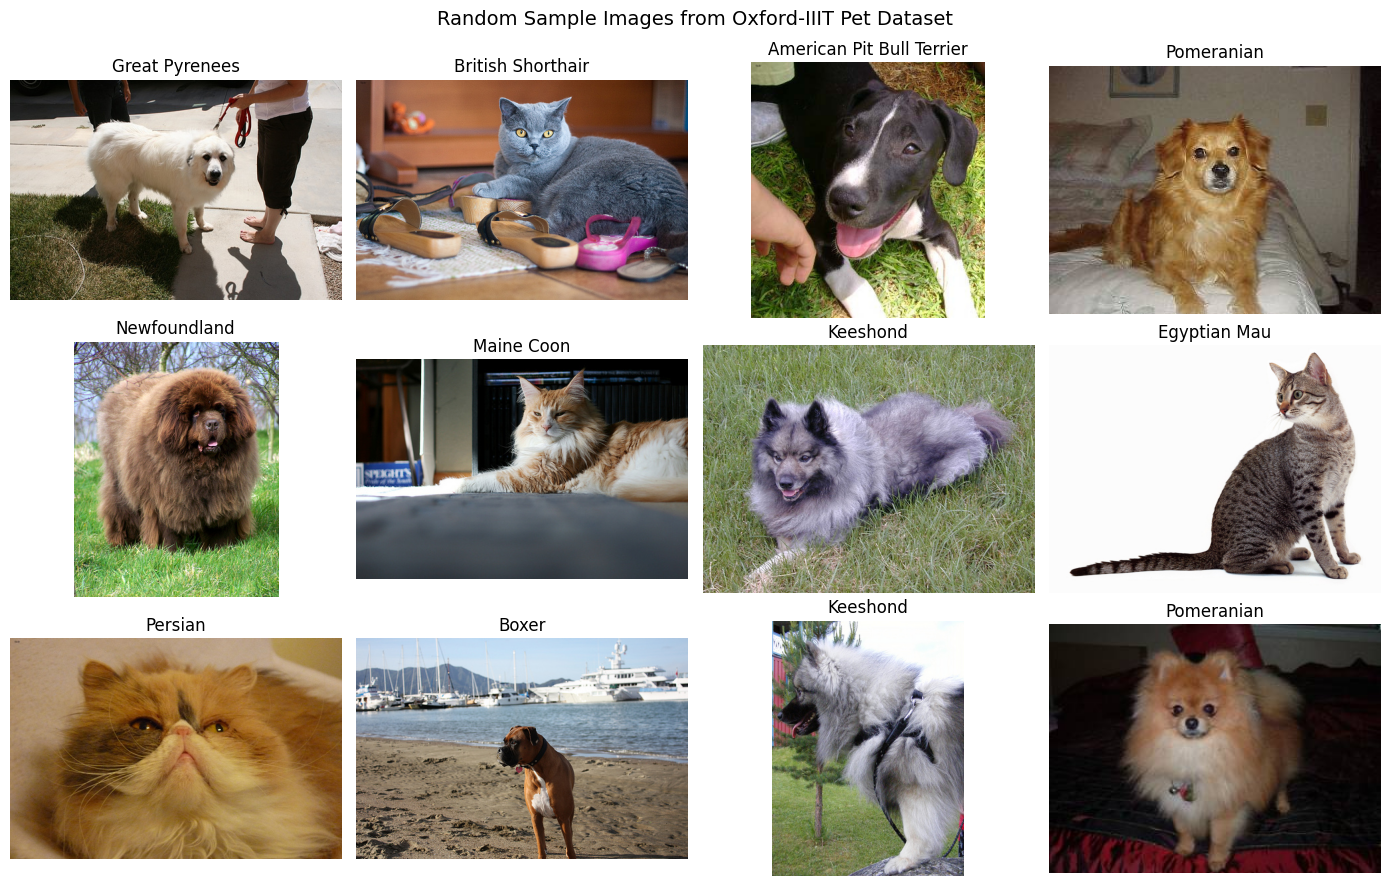

In [7]:
# ============================================================
# 4.3 Exploratory Data Analysis - Visualize Sample Images
# ============================================================

import random

# Create raw datasets only for visualization.
# This avoids displaying normalized/augmented tensors.
eda_visual_trainval_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    download=False,
    transform=None
)

random.seed(seed)
eda_sample_indices = random.sample(range(len(eda_visual_trainval_dataset)), 12)

plt.figure(figsize=(14, 9))

for eda_plot_idx, eda_dataset_idx in enumerate(eda_sample_indices):
    eda_img, eda_label = eda_visual_trainval_dataset[eda_dataset_idx]

    plt.subplot(3, 4, eda_plot_idx + 1)
    plt.imshow(eda_img)
    plt.title(class_names[eda_label])
    plt.axis("off")

plt.suptitle("Random Sample Images from Oxford-IIIT Pet Dataset", fontsize=14)
plt.tight_layout()

plt.savefig("./results/eda_sample_images.png", dpi=150)
plt.show()

In [8]:
# ============================================================
# 4.4 Exploratory Data Analysis - Pixel Statistics
# ============================================================

# Use a lightweight transform only for pixel statistics.
# No augmentation, no normalization.
eda_pixel_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

eda_pixel_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    download=False,
    transform=eda_pixel_transform
)

eda_pixel_loader = DataLoader(
    eda_pixel_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

eda_channel_sum = torch.zeros(3)
eda_channel_squared_sum = torch.zeros(3)
eda_num_pixels = 0

for eda_images, _ in eda_pixel_loader:
    # eda_images shape: [batch_size, channels, height, width]
    eda_channel_sum += eda_images.sum(dim=[0, 2, 3])
    eda_channel_squared_sum += (eda_images ** 2).sum(dim=[0, 2, 3])
    eda_num_pixels += eda_images.shape[0] * eda_images.shape[2] * eda_images.shape[3]

eda_channel_mean = eda_channel_sum / eda_num_pixels
eda_channel_std = torch.sqrt((eda_channel_squared_sum / eda_num_pixels) - (eda_channel_mean ** 2))

print("Pixel mean per channel:")
print(f"Red:   {eda_channel_mean[0]:.4f}")
print(f"Green: {eda_channel_mean[1]:.4f}")
print(f"Blue:  {eda_channel_mean[2]:.4f}")

print("\nPixel std per channel:")
print(f"Red:   {eda_channel_std[0]:.4f}")
print(f"Green: {eda_channel_std[1]:.4f}")
print(f"Blue:  {eda_channel_std[2]:.4f}")

Pixel mean per channel:
Red:   0.4783
Green: 0.4459
Blue:  0.3957

Pixel std per channel:
Red:   0.2611
Green: 0.2556
Blue:  0.2637


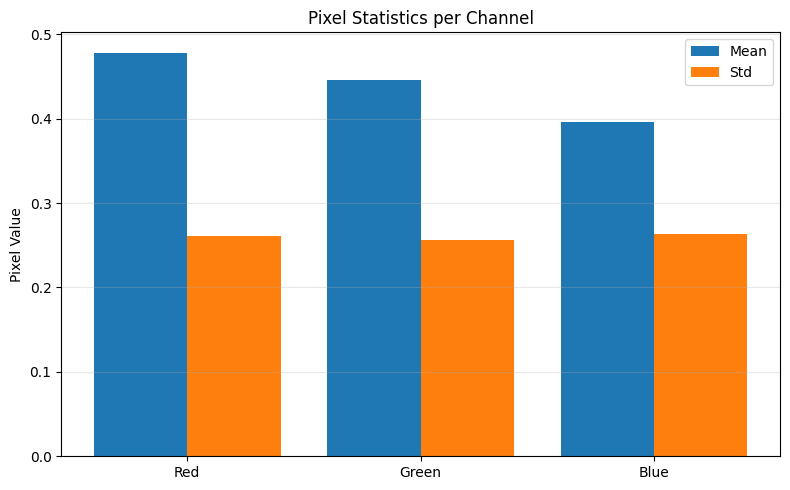

In [9]:
# ============================================================
# 4.5 Exploratory Data Analysis - Pixel Statistics Plot
# ============================================================

eda_channels = ["Red", "Green", "Blue"]
eda_mean_values = eda_channel_mean.numpy()
eda_std_values = eda_channel_std.numpy()

eda_x = range(len(eda_channels))

plt.figure(figsize=(8, 5))

plt.bar(
    [eda_pos - 0.2 for eda_pos in eda_x],
    eda_mean_values,
    width=0.4,
    label="Mean"
)

plt.bar(
    [eda_pos + 0.2 for eda_pos in eda_x],
    eda_std_values,
    width=0.4,
    label="Std"
)

plt.xticks(eda_x, eda_channels)
plt.ylabel("Pixel Value")
plt.title("Pixel Statistics per Channel")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("./results/eda_pixel_statistics.png", dpi=150)
plt.show()

In [10]:
# ============================================================
# 5. Stratified Train / Validation Split
# ============================================================

labels = [full_train_dataset[i][1] for i in range(len(full_train_dataset))]
indices = np.arange(len(full_train_dataset))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=seed,
    stratify=labels
)

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset   = Subset(full_eval_dataset,  val_indices)

print("Train images:",      len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:",       len(test_dataset))

Train images: 2944
Validation images: 736
Test images: 3669


In [11]:
# ============================================================
# 6. DataLoaders (baseline — BATCH_SIZE = 32)
# ============================================================

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [12]:
# ============================================================
# 7. Improved Baseline CNN Model
# ============================================================

class SimpleCNN(nn.Module):
    """
    4 blocks x 2 convs = 8 convolution layers.
    Uses BatchNorm, ReLU, MaxPool, Global Average Pooling, Dropout.
    """

    def __init__(self, num_classes: int = 37, dropout: float = 0.3):
        super().__init__()

        def block(in_c: int, out_c: int) -> nn.Sequential:
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),

                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),

                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            block(3, 32),
            block(32, 64),
            block(64, 128),
            block(128, 256),
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.head(x)
        return x

In [13]:
# ============================================================
# 8. Create Model Instance (BASELINE — do not change)
# ============================================================

model = SimpleCNN(num_classes=num_classes, dropout=0.4).to(device)
print(model)


SimpleCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inpl

In [14]:
# ============================================================
# 9. Loss, Optimizer and Scheduler (BASELINE — do not change)
# ============================================================

EPOCHS  = 100
LR      = 0.001
WD      = 0.0005
WARMUP  = 5

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

warmup_scheduler  = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP)
cosine_scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP)
scheduler         = optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP])

In [15]:
# ============================================================
# 10. Train One Epoch Function
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds      = torch.max(outputs, 1)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

    return running_loss / total, correct / total

In [16]:
# ============================================================
# 11. Evaluation Function
# ============================================================

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total   = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds      = torch.max(outputs, 1)
            correct      += (preds == labels).sum().item()
            total        += labels.size(0)

    return running_loss / total, correct / total

In [17]:
# ============================================================
# 12. Training Loop (BASELINE)
# ============================================================

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}

best_val_acc    = 0.0
best_model_path = "./models/oxford_pet_simplecnn_best.pth"

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)
    current_lr            = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    scheduler.step()

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.6f}"
    )

print(f"Best Validation Accuracy: {best_val_acc:.4f}")

Epoch [1/100] Train Loss: 3.6357 | Train Acc: 0.0397 | Val Loss: 3.4954 | Val Acc: 0.0666 | LR: 0.000100
Epoch [2/100] Train Loss: 3.5160 | Train Acc: 0.0703 | Val Loss: 3.4296 | Val Acc: 0.0761 | LR: 0.000280
Epoch [3/100] Train Loss: 3.4727 | Train Acc: 0.0774 | Val Loss: 3.4438 | Val Acc: 0.0802 | LR: 0.000460
Epoch [4/100] Train Loss: 3.4362 | Train Acc: 0.0822 | Val Loss: 3.4768 | Val Acc: 0.0802 | LR: 0.000640
Epoch [5/100] Train Loss: 3.3863 | Train Acc: 0.1029 | Val Loss: 3.3748 | Val Acc: 0.1060 | LR: 0.000820
Epoch [6/100] Train Loss: 3.2970 | Train Acc: 0.1199 | Val Loss: 3.3808 | Val Acc: 0.1087 | LR: 0.001000
Epoch [7/100] Train Loss: 3.2517 | Train Acc: 0.1230 | Val Loss: 3.4151 | Val Acc: 0.1196 | LR: 0.001000
Epoch [8/100] Train Loss: 3.1770 | Train Acc: 0.1423 | Val Loss: 3.5230 | Val Acc: 0.1073 | LR: 0.000999
Epoch [9/100] Train Loss: 3.1052 | Train Acc: 0.1624 | Val Loss: 3.1642 | Val Acc: 0.1495 | LR: 0.000998
Epoch [10/100] Train Loss: 3.0162 | Train Acc: 0.1804 |

---
# BASELINE FINAL EVALUATION

This section evaluates the best saved Baseline CNN checkpoint on the Oxford-IIIT Pet test set.
It adds the same type of outputs used for the transfer-learning notebooks: test evaluation, classification report, and confusion matrix.

The variables are prefixed with `baseline_eval_` to avoid interfering with the training loop or experiment variables.


In [18]:
# ============================================================
# 13. Baseline CNN - Test Evaluation
# ============================================================

# Load the best checkpoint saved during the baseline training loop.
# This avoids evaluating the final epoch if the best validation epoch happened earlier.
if not os.path.exists(best_model_path):
    raise FileNotFoundError(
        f"Best baseline checkpoint not found at: {best_model_path}. "
        "Run the training loop first so the checkpoint is created."
    )

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

baseline_eval_test_loss = 0.0
baseline_eval_all_preds = []
baseline_eval_all_labels = []

with torch.no_grad():
    for baseline_eval_images, baseline_eval_labels in test_loader:
        baseline_eval_images = baseline_eval_images.to(device)
        baseline_eval_labels = baseline_eval_labels.to(device)

        baseline_eval_outputs = model(baseline_eval_images)
        baseline_eval_loss = criterion(baseline_eval_outputs, baseline_eval_labels)

        baseline_eval_test_loss += baseline_eval_loss.item() * baseline_eval_images.size(0)

        _, baseline_eval_preds = torch.max(baseline_eval_outputs, 1)

        baseline_eval_all_preds.extend(baseline_eval_preds.cpu().numpy())
        baseline_eval_all_labels.extend(baseline_eval_labels.cpu().numpy())

baseline_eval_test_loss = baseline_eval_test_loss / len(test_loader.dataset)
baseline_eval_test_acc = accuracy_score(baseline_eval_all_labels, baseline_eval_all_preds)
baseline_eval_precision_macro = precision_score(
    baseline_eval_all_labels,
    baseline_eval_all_preds,
    average="macro",
    zero_division=0
)
baseline_eval_recall_macro = recall_score(
    baseline_eval_all_labels,
    baseline_eval_all_preds,
    average="macro",
    zero_division=0
)

print("Baseline CNN - Test Evaluation")
print(f"Test Loss: {baseline_eval_test_loss:.4f}")
print(f"Test Accuracy: {baseline_eval_test_acc:.4f}")
print(f"Macro Precision: {baseline_eval_precision_macro:.4f}")
print(f"Macro Recall: {baseline_eval_recall_macro:.4f}")


Baseline CNN - Test Evaluation
Test Loss: 1.6081
Test Accuracy: 0.6225
Macro Precision: 0.6242
Macro Recall: 0.6222


In [19]:
# ============================================================
# 14. Baseline CNN - Classification Report
# ============================================================

baseline_eval_classification_report = classification_report(
    baseline_eval_all_labels,
    baseline_eval_all_preds,
    target_names=class_names,
    zero_division=0
)

print("Classification Report - Baseline CNN")
print(baseline_eval_classification_report)

baseline_eval_report_path = "./results/baseline_classification_report.txt"
with open(baseline_eval_report_path, "w") as baseline_eval_report_file:
    baseline_eval_report_file.write("Classification Report - Baseline CNN\n\n")
    baseline_eval_report_file.write(baseline_eval_classification_report)

print(f"Classification report saved to: {baseline_eval_report_path}")


Classification Report - Baseline CNN
                            precision    recall  f1-score   support

                Abyssinian       0.63      0.63      0.63        98
          American Bulldog       0.47      0.66      0.55       100
 American Pit Bull Terrier       0.47      0.17      0.25       100
              Basset Hound       0.58      0.65      0.61       100
                    Beagle       0.43      0.53      0.48       100
                    Bengal       0.61      0.67      0.64       100
                    Birman       0.67      0.72      0.70       100
                    Bombay       0.74      0.70      0.72        88
                     Boxer       0.55      0.71      0.62        99
         British Shorthair       0.59      0.66      0.62       100
                 Chihuahua       0.36      0.19      0.25       100
              Egyptian Mau       0.74      0.87      0.80        97
    English Cocker Spaniel       0.48      0.50      0.49       100
          

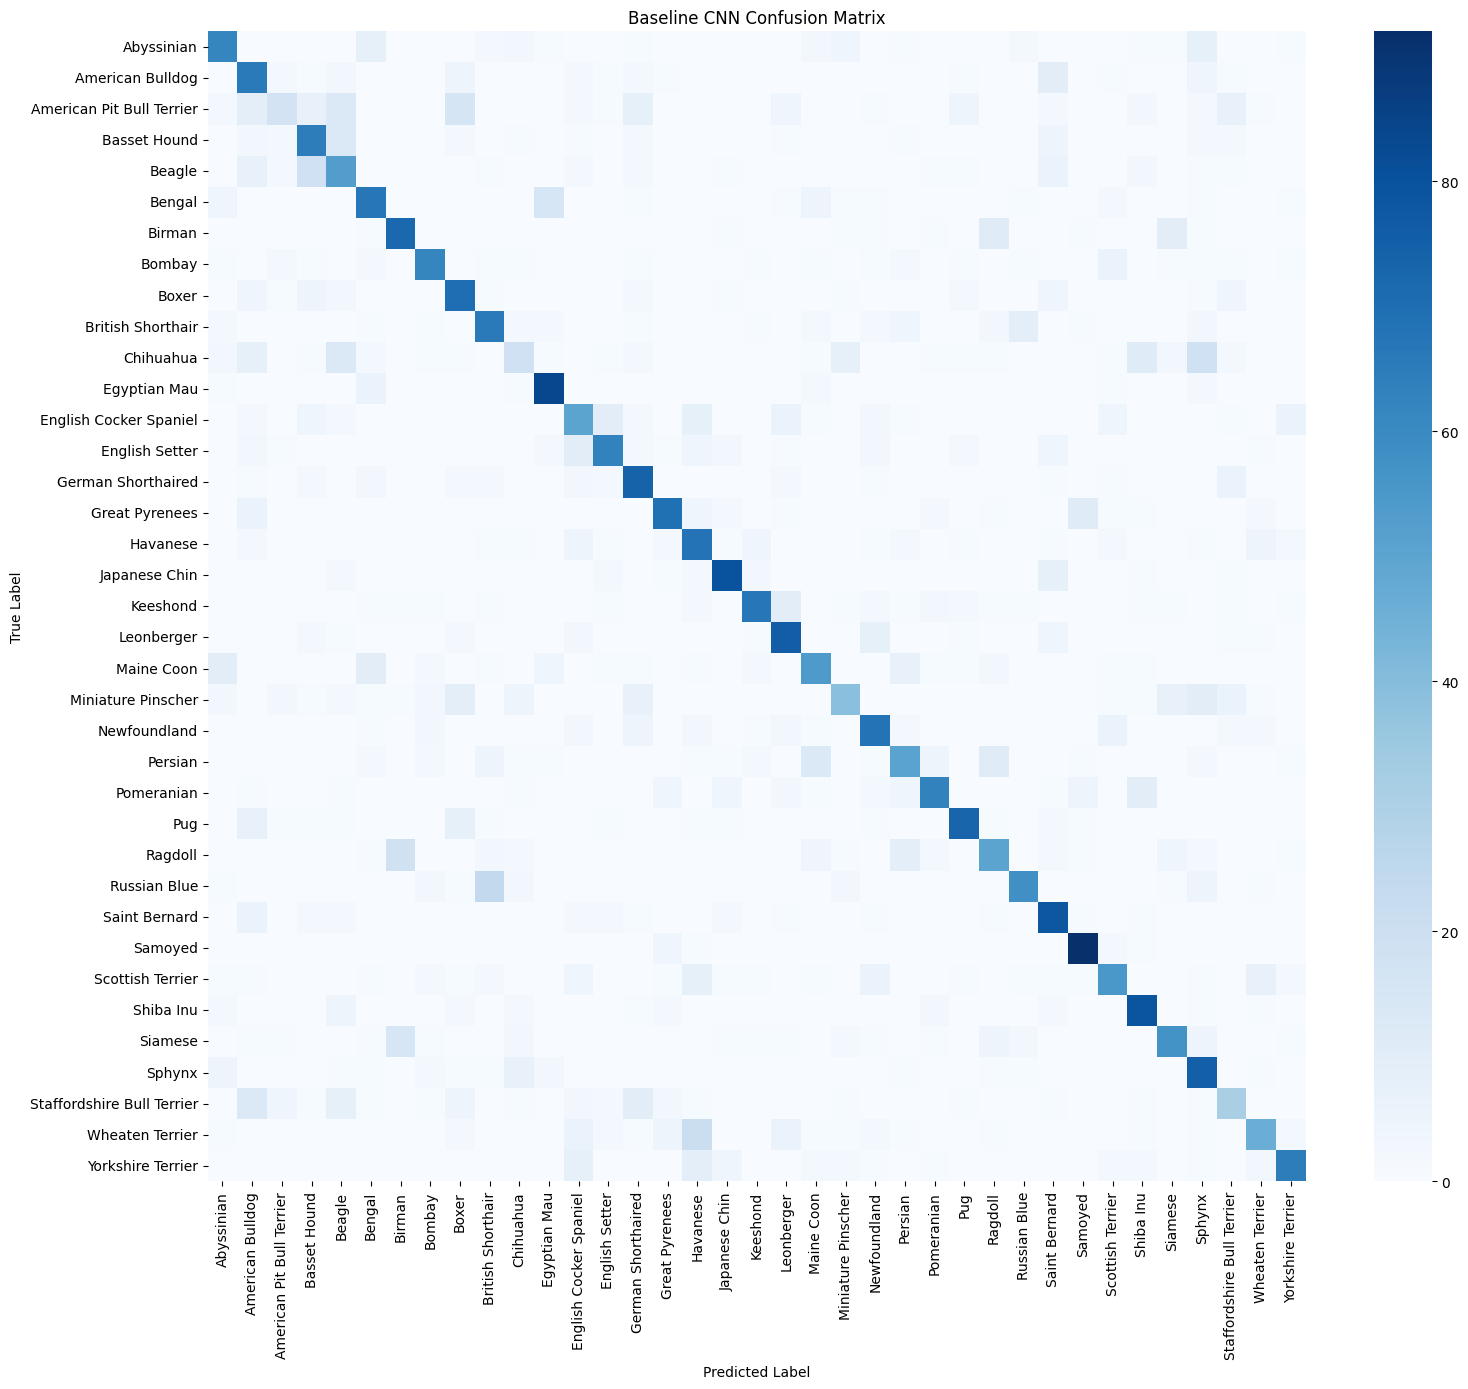

Confusion matrix saved to: ./results/baseline_confusion_matrix.png


In [20]:
# ============================================================
# 15. Baseline CNN - Confusion Matrix
# ============================================================

baseline_eval_cm = confusion_matrix(
    baseline_eval_all_labels,
    baseline_eval_all_preds
)

plt.figure(figsize=(16, 14))

sns.heatmap(
    baseline_eval_cm,
    annot=False,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Baseline CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

baseline_eval_cm_path = "./results/baseline_confusion_matrix.png"
plt.savefig(baseline_eval_cm_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Confusion matrix saved to: {baseline_eval_cm_path}")


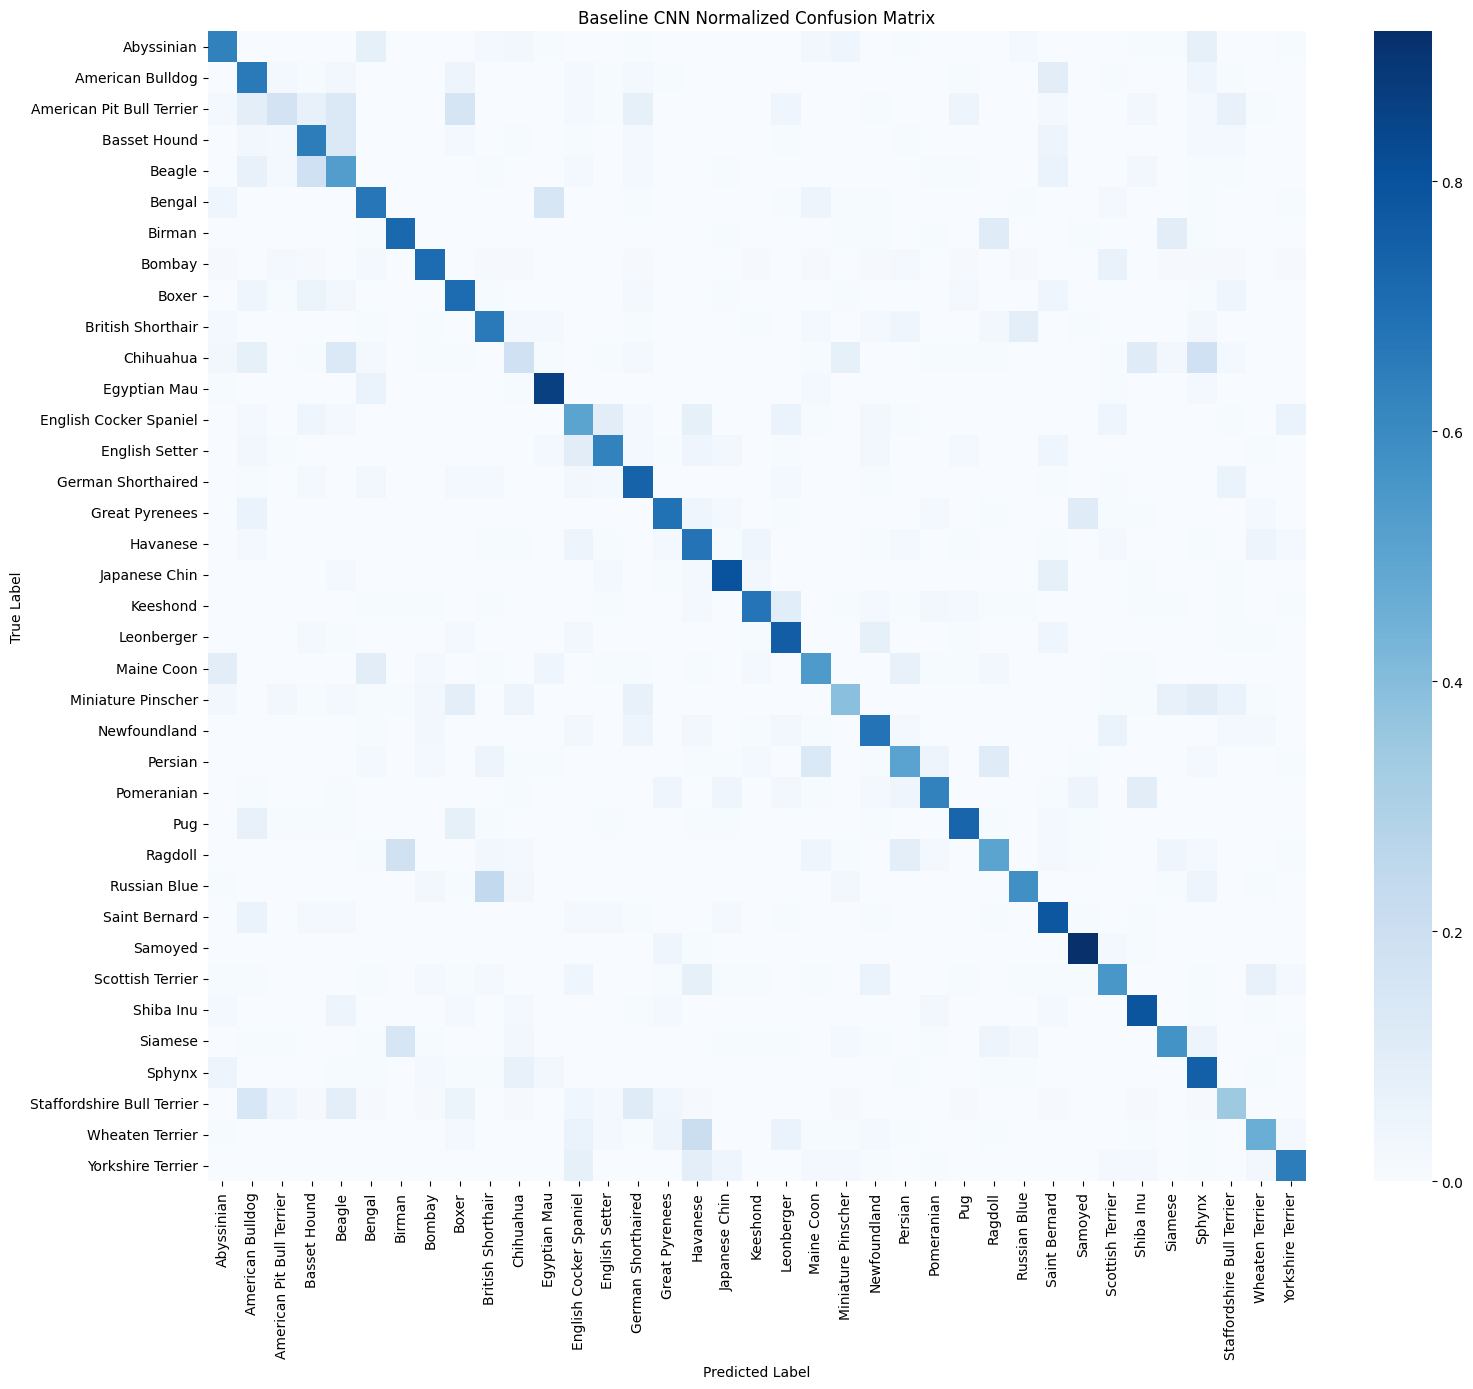

Normalized confusion matrix saved to: ./results/baseline_confusion_matrix_normalized.png


In [21]:
# ============================================================
# 16. Baseline CNN - Normalized Confusion Matrix
# ============================================================

baseline_eval_cm_normalized = baseline_eval_cm.astype("float") / baseline_eval_cm.sum(axis=1)[:, np.newaxis]
baseline_eval_cm_normalized = np.nan_to_num(baseline_eval_cm_normalized)

plt.figure(figsize=(16, 14))

sns.heatmap(
    baseline_eval_cm_normalized,
    annot=False,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Baseline CNN Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

baseline_eval_cm_normalized_path = "./results/baseline_confusion_matrix_normalized.png"
plt.savefig(baseline_eval_cm_normalized_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Normalized confusion matrix saved to: {baseline_eval_cm_normalized_path}")


In [22]:
# ============================================================
# 17. Baseline CNN - Final Evaluation Summary
# ============================================================

baseline_eval_summary = {
    "model": "Baseline CNN",
    "best_val_acc": round(float(best_val_acc), 4),
    "test_loss": round(float(baseline_eval_test_loss), 4),
    "test_accuracy": round(float(baseline_eval_test_acc), 4),
    "macro_precision": round(float(baseline_eval_precision_macro), 4),
    "macro_recall": round(float(baseline_eval_recall_macro), 4),
    "classification_report_path": baseline_eval_report_path,
    "confusion_matrix_path": baseline_eval_cm_path,
    "normalized_confusion_matrix_path": baseline_eval_cm_normalized_path,
}

baseline_eval_summary_path = "./results/baseline_evaluation_summary.json"
with open(baseline_eval_summary_path, "w") as baseline_eval_summary_file:
    json.dump(baseline_eval_summary, baseline_eval_summary_file, indent=4)

baseline_eval_summary_df = pd.DataFrame([baseline_eval_summary])
display(baseline_eval_summary_df)

print(f"Evaluation summary saved to: {baseline_eval_summary_path}")


,model,best_val_acc,test_loss,test_accuracy,macro_precision,macro_recall,classification_report_path,confusion_matrix_path,normalized_confusion_matrix_path
0,Baseline CNN,0.7174,1.6081,0.6225,0.6242,0.6222,./results/baseline_classification_report.txt,./results/baseline_confusion_matrix.png,./results/baseline_confusion_matrix_normalized...


Evaluation summary saved to: ./results/baseline_evaluation_summary.json


---
# EXPERIMENTS

The baseline above reaches approximately 71% validation accuracy with the following fixed parameters:
- LR = 0.001 | WD = 0.0005 | BATCH = 32 | DROPOUT = 0.4 | BatchNorm = Yes | 4 blocks (8 conv layers) | Augmentation = moderate

Each experiment below changes **only one variable** at a time compared with the baseline.
All results are stored in the final comparison table.

**EPOCHS_EXP = 30** to save time — enough to compare trends.


In [39]:
# ============================================================
# EXP-0: Helper — complete training function for experiments
# ============================================================

from torch.utils.data import DataLoader, Subset
from sklearn.metrics import precision_score, recall_score

EPOCHS_EXP = 30  # fewer epochs to keep experiment runtime reasonable

# Stores complete learning curves for each experiment, used by the final plots
exp_histories = {}

def make_loaders(batch_size, aug="baseline"):
    """Create train/validation/test loaders using the selected batch size and augmentation setup."""

    if aug == "strong":
        tr = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.RandomRotation(30),
            transforms.ColorJitter(
                brightness=0.4,
                contrast=0.4,
                saturation=0.4,
                hue=0.1
            ),
            transforms.RandomGrayscale(p=0.1),
            transforms.ToTensor(),
            transforms.Normalize(
                [0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]
            ),
            transforms.RandomErasing(p=0.4, scale=(0.02, 0.2))
        ])

    elif aug == "none":
        tr = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(
                [0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]
            )
        ])

    else:
        tr = train_transform

    tr_ds = datasets.OxfordIIITPet(
        root="./data",
        split="trainval",
        target_types="category",
        transform=tr,
        download=False
    )

    ev_ds = datasets.OxfordIIITPet(
        root="./data",
        split="trainval",
        target_types="category",
        transform=eval_transform,
        download=False
    )

    te_ds = datasets.OxfordIIITPet(
        root="./data",
        split="test",
        target_types="category",
        transform=eval_transform,
        download=False
    )

    tr_ds = Subset(tr_ds, train_indices)
    ev_ds = Subset(ev_ds, val_indices)

    trl = DataLoader(
        tr_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    vl = DataLoader(
        ev_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    tel = DataLoader(
        te_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    return trl, vl, tel


def run_experiment(
    name,
    lr,
    batch_size,
    dropout,
    use_batchnorm,
    aug,
    optimizer_type="adamw",
    wd=0.0005,
    epochs=EPOCHS_EXP,
    label_smoothing=0.05,
    scheduler_type="cosine"
):
    """Train one Baseline CNN experiment and return a result dictionary."""

    print(f"\n{'='*70}")
    print(f"  EXP: {name}")
    print(f"  lr={lr} | batch={batch_size} | dropout={dropout} | BN={use_batchnorm}")
    print(f"  aug={aug} | opt={optimizer_type} | wd={wd} | epochs={epochs}")
    print(f"{'='*70}")

    # ------------------------------------------------------------
    # Model
    # ------------------------------------------------------------

    class ExpCNN(nn.Module):
        """Configurable SimpleCNN variant — allows BatchNorm to be enabled or disabled."""

        def __init__(self, num_classes, dropout, use_bn):
            super().__init__()

            def block(in_c, out_c):
                layers = [
                    nn.Conv2d(
                        in_c,
                        out_c,
                        kernel_size=3,
                        padding=1,
                        bias=not use_bn
                    )
                ]

                if use_bn:
                    layers.append(nn.BatchNorm2d(out_c))

                layers.append(nn.ReLU(inplace=True))

                layers.append(
                    nn.Conv2d(
                        out_c,
                        out_c,
                        kernel_size=3,
                        padding=1,
                        bias=not use_bn
                    )
                )

                if use_bn:
                    layers.append(nn.BatchNorm2d(out_c))

                layers.append(nn.ReLU(inplace=True))
                layers.append(nn.MaxPool2d(2))

                return nn.Sequential(*layers)

            self.features = nn.Sequential(
                block(3, 32),
                block(32, 64),
                block(64, 128),
                block(128, 256)
            )

            self.head = nn.Sequential(
                nn.AdaptiveAvgPool2d(1),
                nn.Flatten(),
                nn.Dropout(dropout),
                nn.Linear(256, num_classes)
            )

        def forward(self, x):
            return self.head(self.features(x))

    m = ExpCNN(num_classes, dropout, use_batchnorm).to(device)

    # ------------------------------------------------------------
    # Loaders
    # ------------------------------------------------------------

    trl, vl, tel = make_loaders(batch_size, aug)

    # ------------------------------------------------------------
    # Optimizer
    # ------------------------------------------------------------

    if optimizer_type == "sgd":
        opt = optim.SGD(
            m.parameters(),
            lr=lr,
            momentum=0.9,
            weight_decay=wd
        )
    elif optimizer_type == "adam":
        opt = optim.Adam(
            m.parameters(),
            lr=lr,
            weight_decay=wd
        )
    else:
        opt = optim.AdamW(
            m.parameters(),
            lr=lr,
            weight_decay=wd
        )

    crit = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    if scheduler_type == "cosine":
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    elif scheduler_type == "plateau":
        sched = optim.lr_scheduler.ReduceLROnPlateau(
            opt,
            mode="min",
            factor=0.3,
            patience=3
        )
    else:
        sched = None

    # ------------------------------------------------------------
    # Training
    # ------------------------------------------------------------

    best_val = 0.0
    best_epoch = 0
    best_path = f"./models/{name}_best.pth"

    exp_history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": []
    }

    for epoch in range(epochs):
        current_lr = opt.param_groups[0]["lr"]

        tr_loss, tr_acc = train_one_epoch(
            m,
            trl,
            crit,
            opt,
            device
        )

        vl_loss, vl_acc = evaluate(
            m,
            vl,
            crit,
            device
        )

        exp_history["train_loss"].append(tr_loss)
        exp_history["train_acc"].append(tr_acc)
        exp_history["val_loss"].append(vl_loss)
        exp_history["val_acc"].append(vl_acc)
        exp_history["lr"].append(current_lr)

        if vl_acc > best_val:
            best_val = vl_acc
            best_epoch = epoch + 1
            torch.save(m.state_dict(), best_path)

        if scheduler_type == "plateau":
            sched.step(vl_loss)
        elif sched is not None:
            sched.step()

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.4f} | "
            f"Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc:.4f} | "
            f"Best: {best_val:.4f} | LR: {current_lr:.6f}"
        )

    # Store curves for final plots
    exp_histories[name] = exp_history

    # ------------------------------------------------------------
    # Load best checkpoint before test evaluation
    # ------------------------------------------------------------

    m.load_state_dict(torch.load(best_path, map_location=device))
    m.to(device)
    m.eval()

    # ------------------------------------------------------------
    # Test evaluation
    # ------------------------------------------------------------

    test_loss, test_acc = evaluate(
        m,
        tel,
        crit,
        device
    )

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tel:
            images = images.to(device)
            labels = labels.to(device)

            outputs = m(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    precision = precision_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    print(
        f"  >>> FINAL best_val_acc={best_val:.4f} | "
        f"best_epoch={best_epoch} | "
        f"test_acc={test_acc:.4f} | "
        f"macro_precision={precision:.4f} | "
        f"macro_recall={recall:.4f}"
    )

    return {
        "name": name,
        "model": "Baseline CNN",
        "pretrained": False,
        "strategy": "from_scratch",
        "image_size": IMG_SIZE,
        "lr": lr,
        "batch_size": batch_size,
        "dropout": dropout,
        "batchnorm": use_batchnorm,
        "augmentation": aug,
        "optimizer": optimizer_type,
        "weight_decay": wd,
        "epochs": epochs,
        "label_smoothing": label_smoothing,
        "scheduler": scheduler_type,
        "best_epoch": best_epoch,
        "best_val_acc": round(best_val, 4),
        "final_val_acc": round(exp_history["val_acc"][-1], 4),
        "test_loss": round(test_loss, 4),
        "test_acc": round(test_acc, 4),
        "macro_precision": round(precision, 4),
        "macro_recall": round(recall, 4)
    }


exp_results = []
print("Baseline experiment helpers ready.")


Baseline experiment helpers ready.


In [40]:
# ============================================================
# EXP 1 — Reference baseline configuration, 30 epochs
# Used as a fair comparison point for the remaining experiments
# ============================================================

r = run_experiment(
    name         = "EXP1_baseline_ref",
    lr           = 0.001,
    batch_size   = 32,
    dropout      = 0.4,
    use_batchnorm= True,
    aug          = 'baseline',
    optimizer_type='adamw'
)
exp_results.append(r)



  EXP: EXP1_baseline_ref
  lr=0.001 | batch=32 | dropout=0.4 | BN=True
  aug=baseline | opt=adamw | wd=0.0005 | epochs=30
Epoch [1/30] Train Loss: 3.6155 | Train Acc: 0.0414 | Val Loss: 3.5301 | Val Acc: 0.0408 | Best: 0.0408 | LR: 0.001000
Epoch [2/30] Train Loss: 3.5305 | Train Acc: 0.0605 | Val Loss: 3.4948 | Val Acc: 0.0503 | Best: 0.0503 | LR: 0.000997
Epoch [3/30] Train Loss: 3.4903 | Train Acc: 0.0666 | Val Loss: 3.4871 | Val Acc: 0.0516 | Best: 0.0516 | LR: 0.000989
Epoch [4/30] Train Loss: 3.4494 | Train Acc: 0.0798 | Val Loss: 3.4300 | Val Acc: 0.0856 | Best: 0.0856 | LR: 0.000976
Epoch [5/30] Train Loss: 3.3830 | Train Acc: 0.0944 | Val Loss: 3.4036 | Val Acc: 0.0802 | Best: 0.0856 | LR: 0.000957
Epoch [6/30] Train Loss: 3.3217 | Train Acc: 0.1043 | Val Loss: 3.6565 | Val Acc: 0.0951 | Best: 0.0951 | LR: 0.000933
Epoch [7/30] Train Loss: 3.2547 | Train Acc: 0.1247 | Val Loss: 3.3687 | Val Acc: 0.0992 | Best: 0.0992 | LR: 0.000905
Epoch [8/30] Train Loss: 3.1990 | Train Acc:

In [41]:
# ============================================================
# EXP 2 — Lower Learning Rate: 0.0001 instead of 0.001
# Question: does the model converge more slowly but generalize better?
# ============================================================

r = run_experiment(
    name         = "EXP2_lr_0001",
    lr           = 0.0001,   # <-- change
    batch_size   = 32,
    dropout      = 0.4,
    use_batchnorm= True,
    aug          = 'baseline',
    optimizer_type='adamw'
)
exp_results.append(r)



  EXP: EXP2_lr_0001
  lr=0.0001 | batch=32 | dropout=0.4 | BN=True
  aug=baseline | opt=adamw | wd=0.0005 | epochs=30
Epoch [1/30] Train Loss: 3.6247 | Train Acc: 0.0438 | Val Loss: 3.4774 | Val Acc: 0.0720 | Best: 0.0720 | LR: 0.000100
Epoch [2/30] Train Loss: 3.5037 | Train Acc: 0.0717 | Val Loss: 3.4254 | Val Acc: 0.0815 | Best: 0.0815 | LR: 0.000100
Epoch [3/30] Train Loss: 3.4347 | Train Acc: 0.0849 | Val Loss: 3.3729 | Val Acc: 0.0978 | Best: 0.0978 | LR: 0.000099
Epoch [4/30] Train Loss: 3.3800 | Train Acc: 0.0941 | Val Loss: 3.3427 | Val Acc: 0.1182 | Best: 0.1182 | LR: 0.000098
Epoch [5/30] Train Loss: 3.3275 | Train Acc: 0.1192 | Val Loss: 3.3052 | Val Acc: 0.1291 | Best: 0.1291 | LR: 0.000096
Epoch [6/30] Train Loss: 3.2861 | Train Acc: 0.1277 | Val Loss: 3.2617 | Val Acc: 0.1304 | Best: 0.1304 | LR: 0.000093
Epoch [7/30] Train Loss: 3.2464 | Train Acc: 0.1396 | Val Loss: 3.2083 | Val Acc: 0.1495 | Best: 0.1495 | LR: 0.000090
Epoch [8/30] Train Loss: 3.1940 | Train Acc: 0.1

In [42]:
# ============================================================
# EXP 3 — Larger Batch Size: 64 instead of 32
# Question: do more stable gradients help, or does generalization degrade?
# ============================================================

r = run_experiment(
    name         = "EXP3_batch64",
    lr           = 0.001,
    batch_size   = 64,        # <-- change
    dropout      = 0.4,
    use_batchnorm= True,
    aug          = 'baseline',
    optimizer_type='adamw'
)
exp_results.append(r)



  EXP: EXP3_batch64
  lr=0.001 | batch=64 | dropout=0.4 | BN=True
  aug=baseline | opt=adamw | wd=0.0005 | epochs=30
Epoch [1/30] Train Loss: 3.6394 | Train Acc: 0.0377 | Val Loss: 3.6645 | Val Acc: 0.0380 | Best: 0.0380 | LR: 0.001000
Epoch [2/30] Train Loss: 3.5396 | Train Acc: 0.0625 | Val Loss: 3.5142 | Val Acc: 0.0584 | Best: 0.0584 | LR: 0.000997
Epoch [3/30] Train Loss: 3.5000 | Train Acc: 0.0673 | Val Loss: 3.4995 | Val Acc: 0.0639 | Best: 0.0639 | LR: 0.000989
Epoch [4/30] Train Loss: 3.4568 | Train Acc: 0.0812 | Val Loss: 3.4899 | Val Acc: 0.0707 | Best: 0.0707 | LR: 0.000976
Epoch [5/30] Train Loss: 3.4305 | Train Acc: 0.0819 | Val Loss: 3.5240 | Val Acc: 0.0611 | Best: 0.0707 | LR: 0.000957
Epoch [6/30] Train Loss: 3.3964 | Train Acc: 0.0931 | Val Loss: 3.4514 | Val Acc: 0.0761 | Best: 0.0761 | LR: 0.000933
Epoch [7/30] Train Loss: 3.3421 | Train Acc: 0.1067 | Val Loss: 3.3599 | Val Acc: 0.1033 | Best: 0.1033 | LR: 0.000905
Epoch [8/30] Train Loss: 3.2981 | Train Acc: 0.12

In [43]:
# ============================================================
# EXP 4 — No Dropout
# Question: is dropout helping, or is it mostly redundant with BatchNorm?
# ============================================================

r = run_experiment(
    name         = "EXP4_no_dropout",
    lr           = 0.001,
    batch_size   = 32,
    dropout      = 0.0,       # <-- change
    use_batchnorm= True,
    aug          = 'baseline',
    optimizer_type='adamw'
)
exp_results.append(r)



  EXP: EXP4_no_dropout
  lr=0.001 | batch=32 | dropout=0.0 | BN=True
  aug=baseline | opt=adamw | wd=0.0005 | epochs=30
Epoch [1/30] Train Loss: 3.6220 | Train Acc: 0.0401 | Val Loss: 3.5706 | Val Acc: 0.0435 | Best: 0.0435 | LR: 0.001000
Epoch [2/30] Train Loss: 3.5454 | Train Acc: 0.0557 | Val Loss: 3.5462 | Val Acc: 0.0639 | Best: 0.0639 | LR: 0.000997
Epoch [3/30] Train Loss: 3.5005 | Train Acc: 0.0594 | Val Loss: 3.5945 | Val Acc: 0.0652 | Best: 0.0652 | LR: 0.000989
Epoch [4/30] Train Loss: 3.4577 | Train Acc: 0.0683 | Val Loss: 3.5464 | Val Acc: 0.0625 | Best: 0.0652 | LR: 0.000976
Epoch [5/30] Train Loss: 3.4054 | Train Acc: 0.0931 | Val Loss: 3.5281 | Val Acc: 0.0774 | Best: 0.0774 | LR: 0.000957
Epoch [6/30] Train Loss: 3.3616 | Train Acc: 0.0978 | Val Loss: 3.4402 | Val Acc: 0.0829 | Best: 0.0829 | LR: 0.000933
Epoch [7/30] Train Loss: 3.2738 | Train Acc: 0.1243 | Val Loss: 3.5016 | Val Acc: 0.0829 | Best: 0.0829 | LR: 0.000905
Epoch [8/30] Train Loss: 3.2594 | Train Acc: 0

In [44]:
# ============================================================
# EXP 5 — No BatchNorm
# Question: how much does BatchNorm contribute to baseline performance?
# ============================================================

r = run_experiment(
    name         = "EXP5_no_batchnorm",
    lr           = 0.001,
    batch_size   = 32,
    dropout      = 0.4,
    use_batchnorm= False,     # <-- change
    aug          = 'baseline',
    optimizer_type='adamw'
)
exp_results.append(r)



  EXP: EXP5_no_batchnorm
  lr=0.001 | batch=32 | dropout=0.4 | BN=False
  aug=baseline | opt=adamw | wd=0.0005 | epochs=30
Epoch [1/30] Train Loss: 3.6127 | Train Acc: 0.0231 | Val Loss: 3.6112 | Val Acc: 0.0272 | Best: 0.0272 | LR: 0.001000
Epoch [2/30] Train Loss: 3.6119 | Train Acc: 0.0251 | Val Loss: 3.6111 | Val Acc: 0.0272 | Best: 0.0272 | LR: 0.000997
Epoch [3/30] Train Loss: 3.6119 | Train Acc: 0.0207 | Val Loss: 3.6110 | Val Acc: 0.0272 | Best: 0.0272 | LR: 0.000989
Epoch [4/30] Train Loss: 3.6118 | Train Acc: 0.0234 | Val Loss: 3.6110 | Val Acc: 0.0272 | Best: 0.0272 | LR: 0.000976
Epoch [5/30] Train Loss: 3.6116 | Train Acc: 0.0258 | Val Loss: 3.6109 | Val Acc: 0.0272 | Best: 0.0272 | LR: 0.000957
Epoch [6/30] Train Loss: 3.6117 | Train Acc: 0.0245 | Val Loss: 3.6109 | Val Acc: 0.0272 | Best: 0.0272 | LR: 0.000933
Epoch [7/30] Train Loss: 3.6116 | Train Acc: 0.0245 | Val Loss: 3.6109 | Val Acc: 0.0272 | Best: 0.0272 | LR: 0.000905
Epoch [8/30] Train Loss: 3.6114 | Train Acc

In [45]:
# ============================================================
# EXP 6 — Stronger Data Augmentation
# Question: does more image variation improve generalization?
# ============================================================

r = run_experiment(
    name         = "EXP6_strong_aug",
    lr           = 0.001,
    batch_size   = 32,
    dropout      = 0.4,
    use_batchnorm= True,
    aug          = 'strong',  # <-- change
    optimizer_type='adamw'
)
exp_results.append(r)



  EXP: EXP6_strong_aug
  lr=0.001 | batch=32 | dropout=0.4 | BN=True
  aug=strong | opt=adamw | wd=0.0005 | epochs=30
Epoch [1/30] Train Loss: 3.6574 | Train Acc: 0.0336 | Val Loss: 3.5858 | Val Acc: 0.0435 | Best: 0.0435 | LR: 0.001000
Epoch [2/30] Train Loss: 3.6040 | Train Acc: 0.0391 | Val Loss: 3.5740 | Val Acc: 0.0367 | Best: 0.0435 | LR: 0.000997
Epoch [3/30] Train Loss: 3.5663 | Train Acc: 0.0496 | Val Loss: 3.5355 | Val Acc: 0.0380 | Best: 0.0435 | LR: 0.000989
Epoch [4/30] Train Loss: 3.5604 | Train Acc: 0.0482 | Val Loss: 3.5401 | Val Acc: 0.0285 | Best: 0.0435 | LR: 0.000976
Epoch [5/30] Train Loss: 3.5366 | Train Acc: 0.0571 | Val Loss: 3.5677 | Val Acc: 0.0611 | Best: 0.0611 | LR: 0.000957
Epoch [6/30] Train Loss: 3.5116 | Train Acc: 0.0635 | Val Loss: 3.5102 | Val Acc: 0.0557 | Best: 0.0611 | LR: 0.000933
Epoch [7/30] Train Loss: 3.5067 | Train Acc: 0.0673 | Val Loss: 3.4976 | Val Acc: 0.0652 | Best: 0.0652 | LR: 0.000905
Epoch [8/30] Train Loss: 3.5063 | Train Acc: 0.0

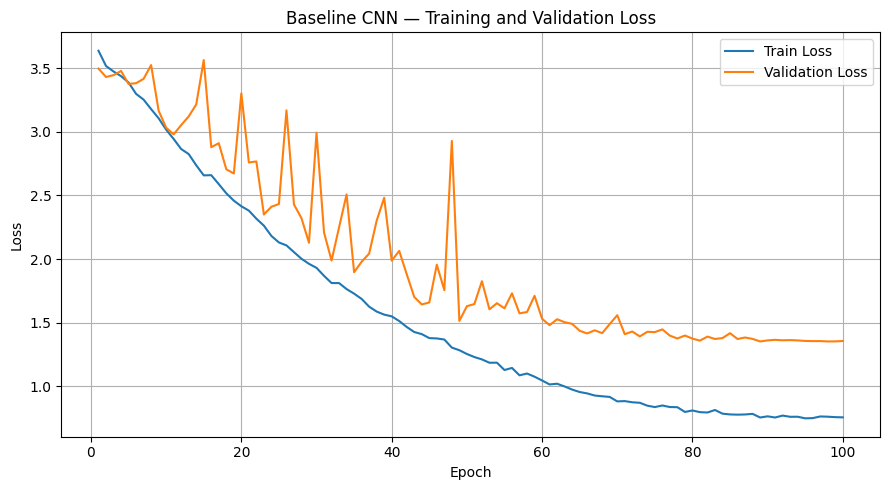

In [54]:
# ============================================================
# VISUALIZATIONS
# ============================================================

# ------------------------------------------------------------
# 1) Main baseline — Loss curves
# ------------------------------------------------------------
epochs_baseline = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_baseline, history["train_loss"], label="Train Loss")
plt.plot(epochs_baseline, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN — Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("./results/baseline_loss_curves.png", dpi=150)
plt.show()


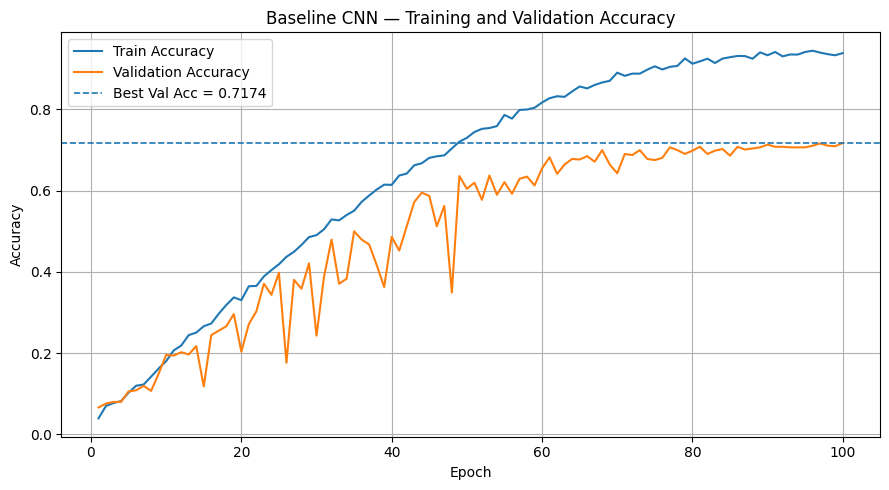

In [48]:
# ------------------------------------------------------------
# 2) Main baseline — Accuracy curves
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.plot(epochs_baseline, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_baseline, history["val_acc"], label="Validation Accuracy")
plt.axhline(y=best_val_acc, linestyle="--", linewidth=1.2, label=f"Best Val Acc = {best_val_acc:.4f}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN — Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("./results/baseline_accuracy_curves.png", dpi=150)
plt.show()


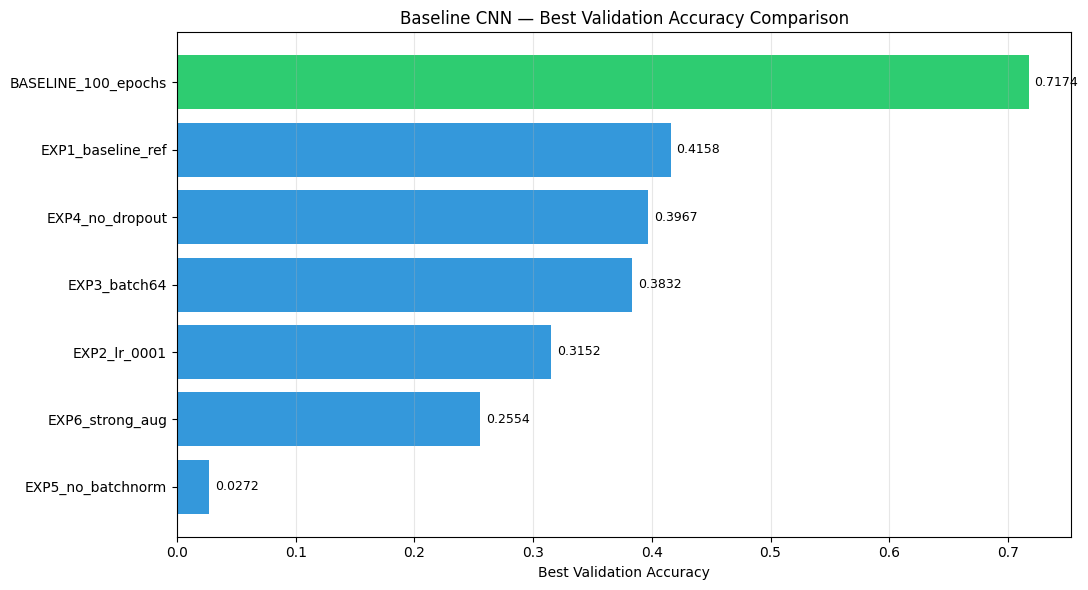

In [49]:
# ------------------------------------------------------------
# 3) Final comparison — Best Validation Accuracy
#    Includes BASELINE_100_epochs + all experiments
# ------------------------------------------------------------
df_plot = df.sort_values("best_val_acc", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ["#2ecc71" if name == "BASELINE_100_epochs" else "#3498db" for name in df_plot["name"]]
bars = ax.barh(df_plot["name"], df_plot["best_val_acc"], color=colors)

ax.set_xlabel("Best Validation Accuracy")
ax.set_title("Baseline CNN — Best Validation Accuracy Comparison")
ax.grid(axis="x", alpha=0.3)

for bar, val in zip(bars, df_plot["best_val_acc"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("./results/comparison_best_val_acc.png", dpi=150)
plt.show()

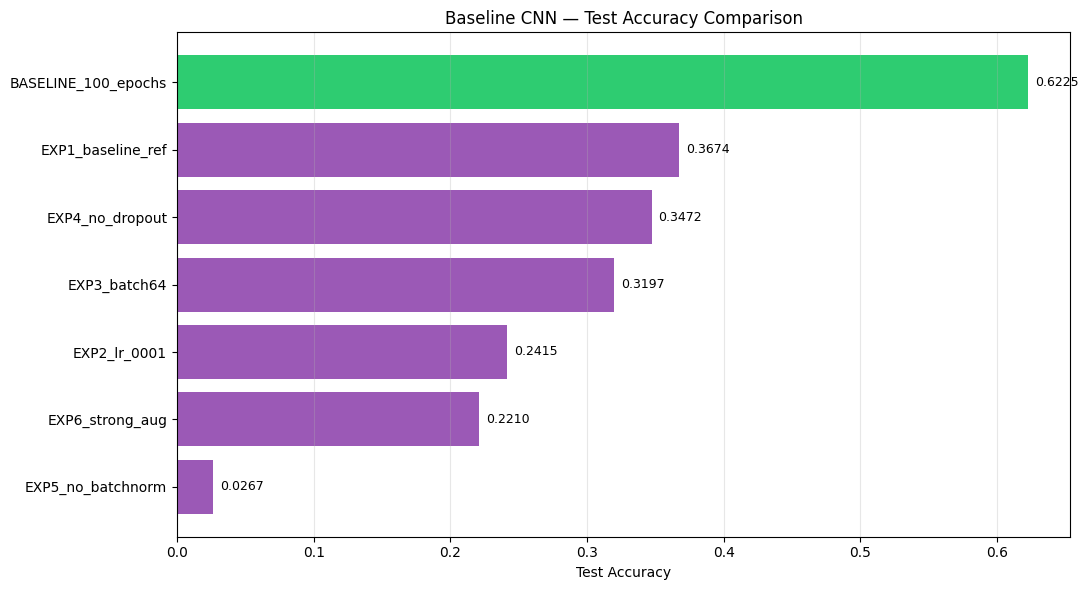

In [50]:
# ------------------------------------------------------------
# 4) Final comparison — Test Accuracy
# ------------------------------------------------------------
df_test = df.dropna(subset=["test_acc"]).sort_values("test_acc", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ["#2ecc71" if name == "BASELINE_100_epochs" else "#9b59b6" for name in df_test["name"]]
bars = ax.barh(df_test["name"], df_test["test_acc"], color=colors)

ax.set_xlabel("Test Accuracy")
ax.set_title("Baseline CNN — Test Accuracy Comparison")
ax.grid(axis="x", alpha=0.3)

for bar, val in zip(bars, df_test["test_acc"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("./results/comparison_test_acc.png", dpi=150)
plt.show()

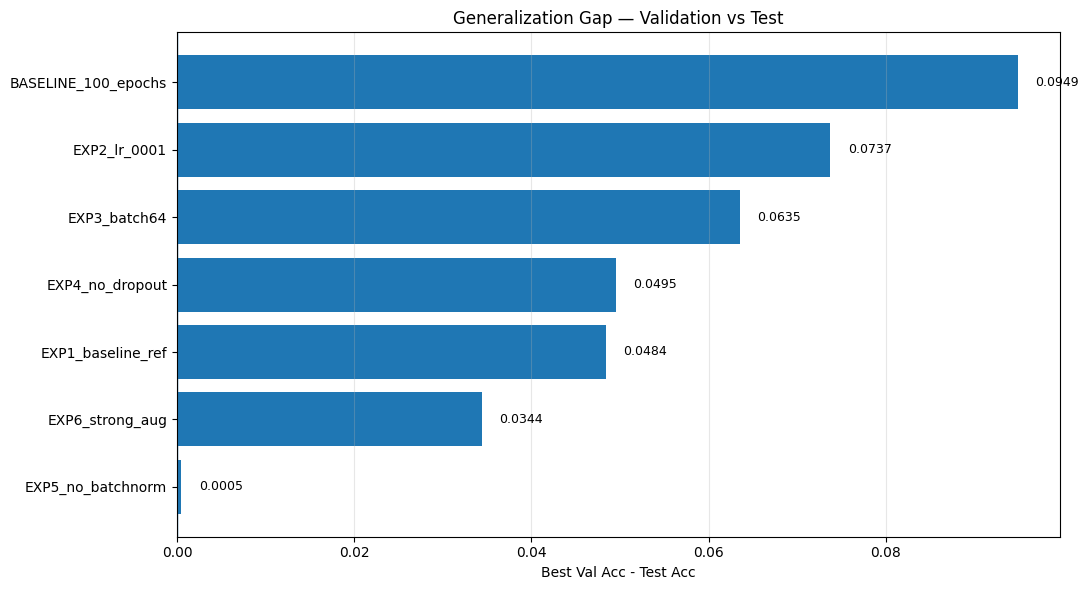

In [51]:
# ------------------------------------------------------------
# 5) Validation/Test gap — helps inspect generalization
# ------------------------------------------------------------
df_gap = df.dropna(subset=["test_acc"]).copy()
df_gap["val_test_gap"] = df_gap["best_val_acc"] - df_gap["test_acc"]
df_gap = df_gap.sort_values("val_test_gap", ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(df_gap["name"], df_gap["val_test_gap"])

ax.axvline(x=0, linewidth=1)
ax.set_xlabel("Best Val Acc - Test Acc")
ax.set_title("Generalization Gap — Validation vs Test")
ax.grid(axis="x", alpha=0.3)

for bar, val in zip(bars, df_gap["val_test_gap"]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("./results/generalization_gap.png", dpi=150)
plt.show()

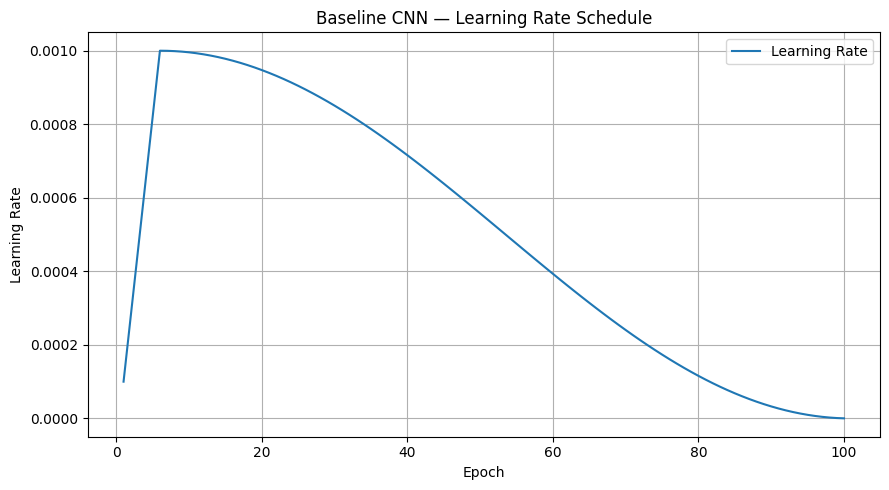

In [52]:


# ------------------------------------------------------------
# 6) Main baseline learning-rate schedule
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.plot(epochs_baseline, history["lr"], label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Baseline CNN — Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("./results/baseline_lr_schedule.png", dpi=150)
plt.show()


## FINAL RESULTS TABLE

In [53]:
# ============================================================
# FINAL RESULTS TABLE - BASELINE CNN
# Same structure as ConvNeXt results table
# ============================================================

import pandas as pd
import numpy as np
import os

from sklearn.metrics import precision_score, recall_score

os.makedirs("./results", exist_ok=True)

# ------------------------------------------------------------
# Evaluate the best saved model from the main 100-epoch baseline
# ------------------------------------------------------------

baseline_test_acc = None
baseline_test_loss = None
baseline_macro_precision = None
baseline_macro_recall = None

if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.to(device)
    model.eval()

    baseline_test_loss, baseline_test_acc = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    baseline_all_preds = []
    baseline_all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            baseline_all_preds.extend(preds.cpu().numpy())
            baseline_all_labels.extend(labels.cpu().numpy())

    baseline_macro_precision = precision_score(
        baseline_all_labels,
        baseline_all_preds,
        average="macro",
        zero_division=0
    )

    baseline_macro_recall = recall_score(
        baseline_all_labels,
        baseline_all_preds,
        average="macro",
        zero_division=0
    )

else:
    print("Warning: best_model_path was not found. The main baseline will be stored without test metrics.")


baseline_result = {
    "name": "BASELINE_100_epochs",
    "model": "Baseline CNN",
    "pretrained": False,
    "strategy": "from_scratch",
    "image_size": IMG_SIZE,
    "lr": LR,
    "batch_size": BATCH_SIZE,
    "dropout": 0.4,
    "batchnorm": True,
    "augmentation": "baseline",
    "optimizer": "adamw",
    "weight_decay": 0.0005,
    "epochs": EPOCHS,
    "label_smoothing": 0.05,
    "scheduler": "cosine",
    "best_epoch": int(np.argmax(history["val_acc"]) + 1),
    "best_val_acc": round(float(best_val_acc), 4),
    "final_val_acc": round(float(history["val_acc"][-1]), 4),
    "test_loss": round(float(baseline_test_loss), 4) if baseline_test_loss is not None else np.nan,
    "test_acc": round(float(baseline_test_acc), 4) if baseline_test_acc is not None else np.nan,
    "macro_precision": round(float(baseline_macro_precision), 4) if baseline_macro_precision is not None else np.nan,
    "macro_recall": round(float(baseline_macro_recall), 4) if baseline_macro_recall is not None else np.nan
}

# ------------------------------------------------------------
# Table with the main baseline + short experiments
# ------------------------------------------------------------

all_results = [baseline_result] + exp_results

df = pd.DataFrame(all_results)

column_order = [
    "name",
    "model",
    "pretrained",
    "strategy",
    "image_size",
    "lr",
    "batch_size",
    "dropout",
    "batchnorm",
    "augmentation",
    "optimizer",
    "weight_decay",
    "epochs",
    "label_smoothing",
    "scheduler",
    "best_epoch",
    "best_val_acc",
    "final_val_acc",
    "test_loss",
    "test_acc",
    "macro_precision",
    "macro_recall"
]

df = df[column_order]

df = df.sort_values(
    by="test_acc",
    ascending=False,
    na_position="last"
).reset_index(drop=True)

display(df)

df.to_csv("./results/baseline_experiment_results.csv", index=False)

print("Saved to ./results/baseline_experiment_results.csv")

,name,model,pretrained,strategy,image_size,lr,batch_size,dropout,batchnorm,augmentation,...,epochs,label_smoothing,scheduler,best_epoch,best_val_acc,final_val_acc,test_loss,test_acc,macro_precision,macro_recall
0,BASELINE_100_epochs,Baseline CNN,False,from_scratch,160,0.0010,32,0.4,True,baseline,...,100,0.05,cosine,100,0.7174,0.7174,1.6081,0.6225,0.6242,0.6222
1,EXP1_baseline_ref,Baseline CNN,False,from_scratch,160,0.0010,32,0.4,True,baseline,...,30,0.05,cosine,30,0.4158,0.4158,2.3244,0.3674,0.3612,0.3684
2,EXP4_no_dropout,Baseline CNN,False,from_scratch,160,0.0010,32,0.0,True,baseline,...,30,0.05,cosine,28,0.3967,0.3954,2.4117,0.3472,0.3506,0.3480
3,EXP3_batch64,Baseline CNN,False,from_scratch,160,0.0010,64,0.4,True,baseline,...,30,0.05,cosine,26,0.3832,0.3832,2.4957,0.3197,0.3117,0.3205
4,EXP2_lr_0001,Baseline CNN,False,from_scratch,160,0.0001,32,0.4,True,baseline,...,30,0.05,cosine,23,0.3152,0.2908,2.8319,0.2415,0.2342,0.2428
5,EXP6_strong_aug,Baseline CNN,False,from_scratch,160,0.0010,32,0.4,True,strong,...,30,0.05,cosine,28,0.2554,0.2541,2.7957,0.2210,0.2185,0.2228
6,EXP5_no_batchnorm,Baseline CNN,False,from_scratch,160,0.0010,32,0.4,False,baseline,...,30,0.05,cosine,1,0.0272,0.0272,3.6113,0.0267,0.0007,0.0270


Saved to ./results/baseline_experiment_results.csv
